# Point 1

In [1]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

2026-03-06 16:39:29.566612: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 16:39:29.633550: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 16:39:36.814287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 16:40:31.626833: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


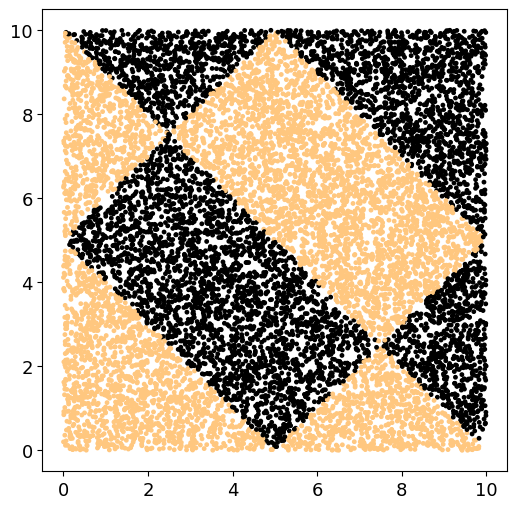

In [2]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

In [3]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
from keras.optimizers import Adam, RMSprop, SGD

# Parametri per la Grid Search
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2]
activations = ['sigmoid', 'relu', 'elu']
dropouts = [0.0, 0.1, 0.2]
optim_names = ['adam', 'rmsprop', 'nesterov']
nepoch = 100

learning_rates_idx = 2
dropouts_idx = 1
activations_idx = 2
optim_names_idx = 0

# Helper per associare nome ottimizzatore, LR -> Oggetto Optimizer
def get_optimizer(opt_name, lr):
    if opt_name == 'adam':
        return keras.optimizers.Adam(learning_rate=lr)
    if opt_name == 'rmsprop':
        return keras.optimizers.RMSprop(learning_rate=lr)
    if opt_name == 'nesterov':
        return keras.optimizers.nesterov(learning_rate=lr)


In [ ]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow as tf
import tensorflow.random as tf_r
tf_r.set_seed(12345)


results_list = []

for lr in learning_rates:
    for activation in activations:
        for drop in dropouts:
            for opt_name in optim_names:
                # "Pulisci" la sessione precedente
                tf.keras.backend.clear_session()

                model = Sequential([
                    Dense(L, input_shape=(L,), activation=activation),
                    Dense(20, activation=activation),
                    Dropout(drop),
                    Dense(20, activation=activation),
                    Dropout(drop),
                    Dense(20, activation=activation),
                    Dropout(drop),
                    Dense(1, activation='sigmoid')
                ])

                optimizer_class = optim_map[opt_name]
                optimizer_inst = optimizer_class(learning_rate=lr)

                # Compilazione e fit del modello
                model.compile(
                    optimizer=optimizer_inst,
                    loss='binary_crossentropy',
                    metrics=['accuracy'],
                )

                fit = model.fit(x_train, y_train,
                    epochs = nepoch, batch_size = 50,
                    validation_data=(x_valid,y_valid),
                    verbose=0
                )

                test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
                res = {
                    'learning_rate': lr,
                    'activation': activation,
                    'dropout': drop,
                    'optimizer': opt_name,
                    'test_loss': test_loss,
                    'test_accuracy': test_acc,
                    'val_loss': history.history['val_loss'][-1], # Ultimo valore di validation
                    'val_accuracy': history.history['val_accuracy'][-1]
                }
                results_list.append(res)
                print(f"Config: {opt_name}, lr={lr}, act={activation} -> Acc: {test_acc:.4f}")


# Saving everything in a Pandas DataFrame and in an external.csv
df_results = pd.DataFrame(results_list)
df_results.to_csv('grid_search_results.csv', index=False)


NameError: name 'tf' is not defined

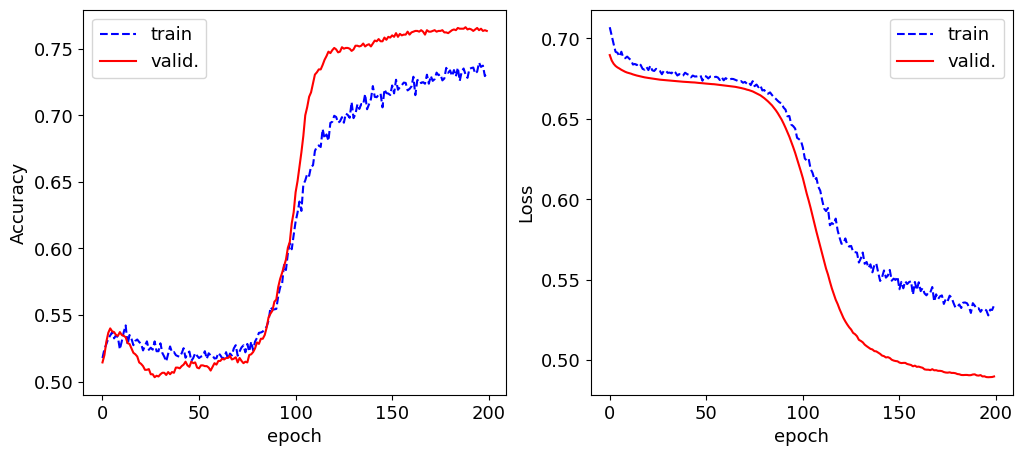

In [51]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

In [52]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.4946
Final test accuracy: 0.7550


319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step


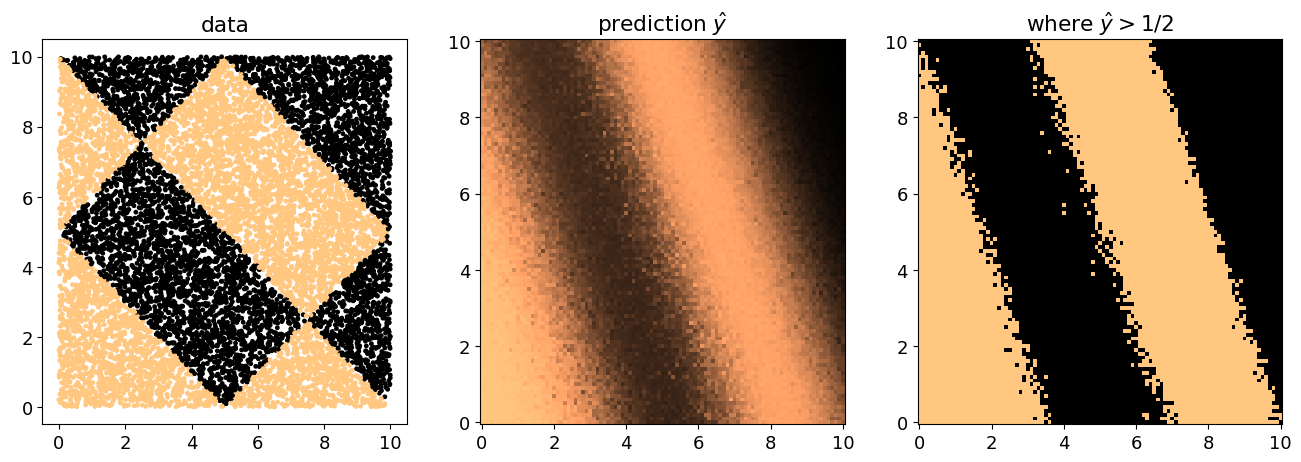

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [53]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")